# Raincloud Plot

This section showcases the raincloud plot. It contains examples of how to create raincloud plots using the [datachart.charts.RaincloudPlot](../../../references/charts/#datachart.charts.RaincloudPlot) function.

Looking for a specific customization? Jump straight to the [quick reference](#customizing-the-raincloud-plot), which maps common tasks to the parameter or style attribute that does the job.

As mentioned above, the raincloud plots are created using the `RaincloudPlot` function found in the [datachart.charts](../../../references/charts/) module. Let's import it:

In [1]:
from datachart.charts import RaincloudPlot

## Raincloud Plot Input Attributes

The `RaincloudPlot` function accepts keyword arguments for chart configuration. The main argument is `data`, which contains the data points. For a single raincloud plot, `data` is a list of dictionaries; the points that share a `label` form one group. For multiple raincloud plots, `data` is a list of lists, and each chart draws in its own subplot.

```python
RaincloudPlot(
    data=[{                                             # A list of data points (or list of lists for multiple charts)
        "label": str,                                   # The category label
        "value": Union[int, float],                     # The numeric value
    }],
    style={                                             # The style of the cloud, the rain, and the box (optional)
        "plot_violin_color":        Union[str, None],       # The cloud fill color
        "plot_violin_alpha":        Union[float, None],     # The alpha of the cloud
        "plot_violin_width":        Union[int, float, None], # The maximum width of the cloud
        "plot_swarm_color":         Union[str, None],       # The rain point color
        "plot_swarm_size":          Union[int, float, None], # The rain point size
        "plot_swarm_alpha":         Union[float, None],     # The alpha of the rain points
        "plot_box_linewidth":       Union[int, float, None], # The line width of the box
        "plot_box_edgecolor":       Union[str, None],       # The edge color of the box
        "plot_box_outlier_size":    Union[int, float, None], # The outlier marker size
    },
    title: Union[str, None],                            # The chart title (optional)
    xlabel: Union[str, None],                           # The x-axis label (optional)
    ylabel: Union[str, None],                           # The y-axis label (optional)
    subtitle: Union[str, List[str], None],              # The subtitle(s), used as subplot titles (optional)
    emphasis: Union[str, List[str], None],              # The emphasis role(s), aligned with the group labels (optional)
    mode: Union[str, None],                             # "swarm" (the default) or "strip" for the rain (optional)
    jitter: Union[float, None],                         # The strip jitter width, a fraction of the category width (optional)
    bandwidth: Union[str, float, None],                 # The cloud's KDE bandwidth rule or factor (optional)
    show_outliers: Union[bool, None],                   # Whether the box shows outliers (optional)
    orientation: Union[str, None],                      # "vertical" (the default) or "horizontal" (optional)
    scaley: Union[str, None],                           # The value axis scale (optional)
    figsize: Union[Tuple[float, float], None],          # The figure size (optional)
    show_legend: Union[bool, None],                     # Whether to show the legend, one entry per group (optional)
    show_grid: Union[str, None],                        # Which grid lines to show (optional)
    subplots: Union[bool, None],                        # Whether to draw each chart in its own subplot (optional)
    max_cols: Union[int, None],                         # The maximum number of subplot columns (optional)
    sharex: Union[bool, None],                          # Whether the subplots share the x-axis (optional)
    sharey: Union[bool, None],                          # Whether the subplots share the y-axis (optional)
    hlines: Union[dict, List[dict], None],              # The horizontal reference lines (optional)
    vlines: Union[dict, List[dict], None],              # The vertical reference lines (optional)
    label: Union[str, None],                            # The key name in `data` holding the label (optional)
    value: Union[str, None],                            # The key name in `data` holding the value (optional)
)
```

For more details, see the [datachart.charts.RaincloudPlot](../../../references/charts/#datachart.charts.RaincloudPlot) function.

## Basics

The examples in this guide share one dataset: the body mass of the 342 penguins of the [Palmer penguins](https://allisonhorst.github.io/palmerpenguins/) dataset (CC0), three species measured on the islands of the Palmer Archipelago in Antarctica. The data is hard-coded in a hidden cell, which keeps the sex and the flipper length of every penguin alongside its species — the later sections reuse them. `chart_data` holds the body mass (in g) of every penguin, labeled with its species.

In [2]:
# the 342 Palmer penguins with a recorded body mass, grouped by species and sex
PENGUINS = [
    {
        "species": "Adelie",
        "sex": "Female",
        "body_mass": [
            3800, 3250, 3450, 3625, 3200, 3700, 3450, 3325, 3400, 3800, 3800, 3200, 3150,
            3250, 3300, 3325, 3550, 3300, 3150, 3100, 3000, 3450, 3500, 3450, 2900, 3550,
            2850, 3150, 3600, 2850, 3350, 3050, 3600, 3550, 3700, 3700, 3550, 3200, 3800,
            3350, 3500, 3600, 3550, 3400, 3300, 3700, 2900, 3725, 3075, 2925, 3750, 3175,
            3825, 3200, 3900, 2900, 3350, 3150, 3450, 3050, 3275, 3050, 3325, 3500, 3425,
            3175, 3400, 3400, 3050, 3000, 3475, 3450, 3700,
        ],
        "flipper_length": [
            186, 195, 193, 181, 182, 185, 195, 184, 174, 189, 187, 187, 172, 178, 188, 195,
            180, 181, 182, 186, 185, 190, 186, 190, 187, 186, 181, 185, 185, 184, 195, 190,
            190, 196, 190, 191, 187, 189, 187, 191, 189, 190, 202, 185, 187, 190, 178, 192,
            183, 193, 199, 181, 198, 193, 191, 188, 189, 187, 176, 186, 191, 191, 190, 193,
            187, 191, 185, 193, 188, 192, 184, 195, 187,
        ],
    },
    {
        "species": "Adelie",
        "sex": "Male",
        "body_mass": [
            3750, 3650, 4675, 3800, 4400, 4500, 4200, 3600, 3950, 3800, 3550, 3950, 3900,
            3900, 4150, 3950, 4650, 3900, 4400, 4600, 3425, 4150, 4300, 4050, 3700, 3800,
            3750, 4400, 4050, 3950, 4100, 4450, 3900, 4150, 4250, 3900, 4000, 4700, 4200,
            3550, 3800, 3950, 4300, 4450, 4300, 4350, 4100, 4725, 4250, 3550, 3900, 4775,
            4600, 4275, 4075, 3775, 3325, 3500, 3875, 4000, 4300, 4000, 3500, 4475, 3900,
            3975, 4250, 3475, 3725, 3650, 4250, 3750, 4000,
        ],
        "flipper_length": [
            181, 190, 195, 191, 198, 197, 194, 180, 185, 180, 183, 180, 178, 184, 196, 190,
            184, 195, 196, 190, 182, 191, 188, 200, 191, 193, 194, 195, 192, 192, 188, 198,
            190, 197, 195, 184, 195, 196, 193, 194, 190, 189, 205, 186, 208, 196, 192, 203,
            190, 184, 190, 197, 191, 197, 196, 199, 189, 198, 202, 199, 195, 210, 197, 199,
            190, 200, 193, 187, 190, 185, 190, 193, 201,
        ],
    },
    {
        "species": "Adelie",
        "sex": None,
        "body_mass": [
            3475, 4250, 3300, 3700, 2975,
        ],
        "flipper_length": [
            193, 190, 186, 180, 179,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Female",
        "body_mass": [
            3500, 3525, 3950, 3250, 4150, 3800, 3700, 3575, 3700, 3450, 3600, 2900, 3300,
            3400, 3700, 3200, 3350, 3900, 3850, 2700, 3650, 3500, 3675, 3400, 3675, 3325,
            3600, 3350, 3250, 3525, 3650, 3650, 3400, 3775,
        ],
        "flipper_length": [
            192, 188, 198, 178, 195, 193, 185, 190, 181, 190, 181, 187, 195, 200, 191, 187,
            187, 199, 195, 192, 187, 196, 196, 190, 198, 199, 193, 187, 191, 194, 189, 195,
            202, 198,
        ],
    },
    {
        "species": "Chinstrap",
        "sex": "Male",
        "body_mass": [
            3900, 3650, 3725, 3750, 3700, 3775, 4050, 4050, 3300, 4400, 3400, 3800, 4150,
            3800, 4550, 4300, 4100, 3600, 4800, 4500, 3950, 3550, 4450, 4300, 3250, 3950,
            4050, 3450, 4050, 3800, 3950, 4000, 3775, 4100,
        ],
        "flipper_length": [
            196, 193, 197, 197, 198, 194, 201, 201, 197, 195, 191, 193, 197, 200, 205, 201,
            203, 195, 210, 205, 210, 196, 201, 212, 187, 201, 203, 197, 203, 202, 206, 207,
            193, 210,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Female",
        "body_mass": [
            4500, 4450, 4550, 4800, 4400, 4650, 4650, 4200, 4150, 4800, 5000, 4400, 5000,
            4600, 4700, 5050, 5150, 4950, 4350, 3950, 4300, 4900, 4200, 5100, 4850, 4400,
            4900, 4300, 4450, 4200, 4400, 4700, 4700, 4750, 5200, 4700, 4600, 4750, 4625,
            4725, 4750, 4600, 4875, 4950, 4750, 4850, 4875, 4625, 4850, 4975, 4700, 4575,
            5000, 4650, 4375, 4925, 4850, 5200,
        ],
        "flipper_length": [
            211, 210, 210, 211, 209, 214, 214, 210, 210, 209, 215, 213, 215, 210, 209, 207,
            220, 213, 208, 208, 210, 217, 210, 213, 210, 210, 217, 208, 208, 208, 214, 219,
            220, 216, 217, 216, 209, 215, 212, 212, 212, 218, 212, 218, 212, 214, 222, 203,
            219, 215, 210, 208, 216, 213, 217, 214, 215, 212,
        ],
    },
    {
        "species": "Gentoo",
        "sex": "Male",
        "body_mass": [
            5700, 5700, 5400, 5200, 5150, 5550, 5850, 5850, 6300, 5350, 5700, 5050, 5100,
            5650, 5550, 5250, 6050, 5400, 5250, 5350, 5700, 4750, 5550, 5400, 5300, 5300,
            5000, 5050, 5000, 5550, 5300, 5650, 5700, 5800, 5550, 5000, 5100, 5800, 6000,
            5950, 5450, 5350, 5600, 5300, 5550, 5400, 5650, 5200, 4925, 5250, 5600, 5500,
            5500, 5500, 5500, 5950, 5500, 5850, 6000, 5750, 5400,
        ],
        "flipper_length": [
            230, 218, 215, 219, 215, 216, 213, 217, 221, 222, 218, 215, 215, 215, 220, 222,
            230, 220, 219, 208, 225, 216, 222, 225, 215, 220, 225, 220, 220, 224, 221, 231,
            230, 229, 223, 221, 221, 230, 220, 223, 221, 224, 228, 218, 230, 228, 224, 226,
            216, 225, 228, 228, 215, 219, 209, 229, 230, 230, 222, 222, 213,
        ],
    },
    {
        "species": "Gentoo",
        "sex": None,
        "body_mass": [
            4100, 4650, 4725, 4875,
        ],
        "flipper_length": [
            216, 214, 216, 217,
        ],
    },
]

chart_data = [
    {"label": penguin["species"], "value": mass}
    for penguin in PENGUINS
    for mass in penguin["body_mass"]
]
flipper_data = [
    {"label": penguin["species"], "value": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

The data is a flat list of dictionaries, one per data point, each with a `label` and a `value`. The points that share a `label` are grouped into one raincloud, so three species give three rainclouds:

In [3]:
chart_data[:3]

[{'label': 'Adelie', 'value': 3800},
 {'label': 'Adelie', 'value': 3250},
 {'label': 'Adelie', 'value': 3450}]

**Basic example.** Only the `data` argument is required to draw the raincloud plot. Every group draws three parts at its position: the **cloud** on the right, a half violin showing the density of the values; the **box** just left of it, the quartile summary with its outliers; and the **rain** further left, every penguin as one point, packed outward from the box. Each species takes its own color, shared by all three parts, so they read as one group.

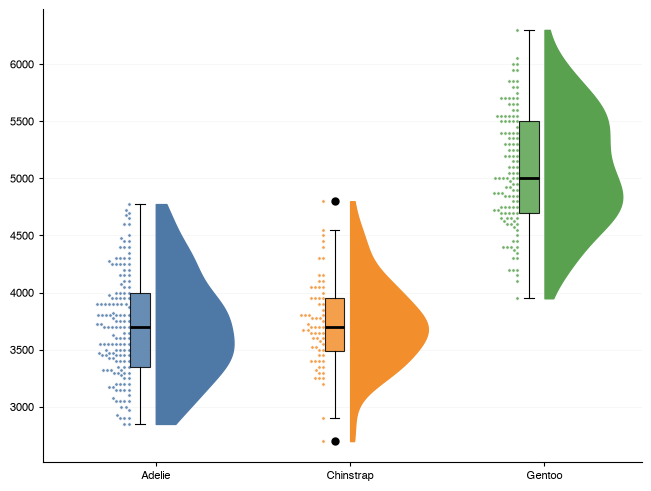

In [4]:
RaincloudPlot(
    # add the data to the chart
    data=chart_data
).show()

## Customizing the Raincloud Plot

Every customization is either a keyword argument of `RaincloudPlot` or an attribute of its `style` dictionary: the `plot_violin_*` attributes style the cloud, the `plot_swarm_*` attributes the rain, and the `plot_box_*` attributes the box. The table maps common tasks to the one you need and links to the subsection that shows it.

| I want to…                                  | Use                                                                     | See |
| :------------------------------------------ | :---------------------------------------------------------------------- | :-- |
| add a title and axis labels                 | `title`, `xlabel`, `ylabel`                                             | [Title and axis labels](#title-and-axis-labels) |
| resize the figure                           | `figsize`                                                               | [Figure size and grid](#figure-size-and-grid) |
| show the grid lines                         | `show_grid`                                                             | [Figure size and grid](#figure-size-and-grid) |
| list the groups in a legend                 | `show_legend`                                                           | [Figure size and grid](#figure-size-and-grid) |
| change the cloud, rain, or box style        | `style={"plot_violin_alpha": ..., "plot_swarm_size": ..., "plot_box_linewidth": ...}` | [Cloud, rain, and box style](#cloud-rain-and-box-style) |
| smooth or sharpen the cloud                 | `bandwidth`                                                             | [Cloud bandwidth](#cloud-bandwidth) |
| jitter the rain instead of packing it       | `mode`, `jitter`                                                        | [Rain modes](#rain-modes) |
| hide the box outliers                       | `show_outliers`                                                         | [Box outliers](#box-outliers) |
| draw the rainclouds horizontally            | `orientation`                                                           | [Raincloud orientation](#raincloud-orientation) |
| highlight one group, mute the rest          | `emphasis`                                                              | [Emphasis](#emphasis) |
| draw a threshold or reference line          | `hlines`, `vlines`                                                      | [Reference lines](#reference-lines) |
| draw each dataset in its own subplot        | `data` as a list of lists, `subplots`, `sharex`, `sharey`               | [Multiple Raincloud Plots](#multiple-raincloud-plots) |
| compose the raincloud with other charts     | `Panel`, `Grid`                                                         | [Composing rainclouds](#composing-rainclouds) |
| use a logarithmic value axis                | `scaley`                                                                | [Logarithmic scale](#logarithmic-scale) |
| save the chart to a file                    | `save_figure`                                                           | [Saving the Chart as an Image](#saving-the-chart-as-an-image) |

The full list of style attributes is in the [datachart.typings.RaincloudStyleAttrs](../../../references/typings/#datachart.typings.RaincloudStyleAttrs) type; the full list of parameters is in the [datachart.charts.RaincloudPlot](../../../references/charts/#datachart.charts.RaincloudPlot) reference.

### Title and axis labels

To add the chart title and axis labels, add the `title`, `xlabel` and `ylabel` attributes.

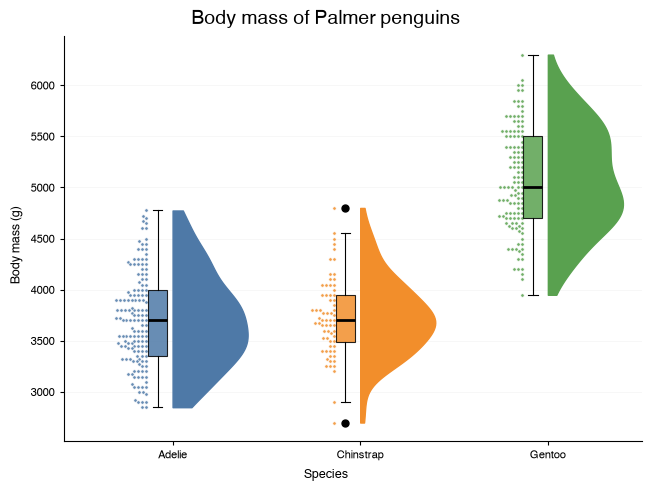

In [5]:
RaincloudPlot(
    data=chart_data,
    # add the title
    title="Body mass of Palmer penguins",
    # add the x and y axis labels
    xlabel="Species",
    ylabel="Body mass (g)",
).show()

### Figure size and grid

To change the figure size, add the `figsize` attribute. The `figsize` attribute can be a tuple (width, height), values are in inches. The `datachart` package provides a [datachart.constants.FIG_SIZE](../../../references/constants/#datachart.constants.FIG_SIZE) constant, which contains predefined figure sizes. To show the grid lines, add the `show_grid` attribute, which supports the values of the [datachart.constants.SHOW_GRID](../../../references/constants/#datachart.constants.SHOW_GRID) constant. To list the groups and their colors, add the `show_legend` attribute.

In [6]:
from datachart.constants import FIG_SIZE, SHOW_GRID

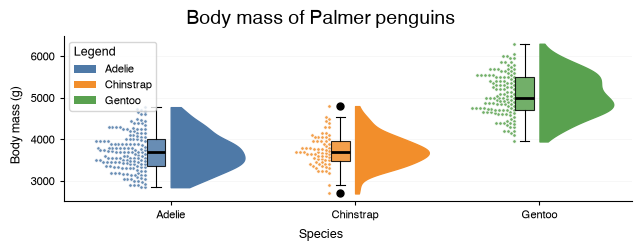

In [7]:
RaincloudPlot(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    # add to determine the figure size
    figsize=FIG_SIZE.FULL_SHORT,
    # add to show the grid lines
    show_grid=SHOW_GRID.Y,
    # one legend entry per group
    show_legend=True,
).show()

### Cloud, rain, and box style

To change the style of the parts, add the `style` attribute with the corresponding attributes. The supported attributes are shown in the [datachart.typings.RaincloudStyleAttrs](../../../references/typings/#datachart.typings.RaincloudStyleAttrs) type: the cloud takes the [datachart.typings.ViolinStyleAttrs](../../../references/typings/#datachart.typings.ViolinStyleAttrs) body attributes, the rain the [datachart.typings.SwarmStyleAttrs](../../../references/typings/#datachart.typings.SwarmStyleAttrs) attributes, and the box the [datachart.typings.BoxStyleAttrs](../../../references/typings/#datachart.typings.BoxStyleAttrs) attributes. The most common ones are:

| Attribute | Description |
| :-------- | :---------- |
| `plot_violin_color` | The cloud fill color; one color for every group instead of the palette. |
| `plot_violin_alpha` | The alpha of the cloud. |
| `plot_violin_width` | The maximum width of the cloud, as a fraction of the category width. |
| `plot_swarm_color` | The rain point color; one color for every group instead of the palette. |
| `plot_swarm_size` | The rain point size, in points squared (6 by default, smaller than a standalone swarm's). |
| `plot_swarm_alpha` | The alpha of the rain points. |
| `plot_box_linewidth` | The line width of the box. |
| `plot_box_edgecolor` | The edge color of the box; the median, whiskers, and caps have their own `plot_box_*_color`. |
| `plot_box_outlier_size` | The outlier marker size. |

The box takes the group color as its fill and the theme's font color for its edges, median, whiskers, and caps.

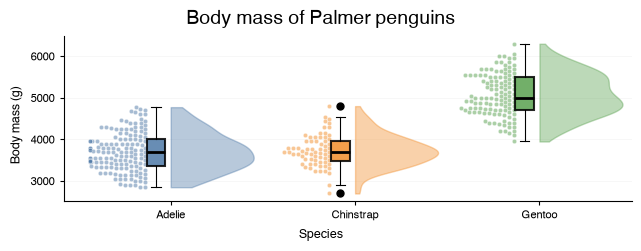

In [8]:
RaincloudPlot(
    data=chart_data,
    # define the style of the cloud, the rain, and the box
    style={
        "plot_violin_alpha": 0.4,
        "plot_violin_width": 0.9,
        "plot_swarm_size": 10,
        "plot_swarm_alpha": 0.5,
        "plot_box_linewidth": 1.5,
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Cloud bandwidth

The cloud is a kernel density estimate of the values. The `bandwidth` attribute sets how much the estimate smooths: a rule of the [datachart.constants.BANDWIDTH](../../../references/constants/#datachart.constants.BANDWIDTH) constant (`"scott"`, the default, or `"silverman"`) or a scalar factor, where smaller values follow the data more closely and larger ones smooth it more.

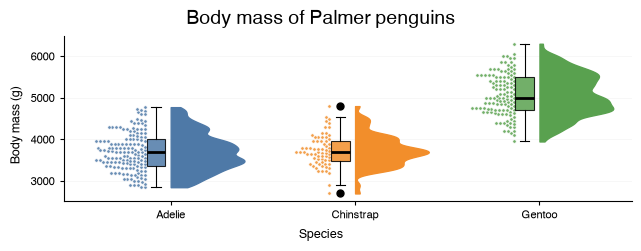

In [9]:
RaincloudPlot(
    data=chart_data,
    # a narrow bandwidth follows the data closely
    bandwidth=0.2,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Rain modes

The `mode` attribute chooses how the rain spreads across its width. It supports the values of the [datachart.constants.SWARM_MODE](../../../references/constants/#datachart.constants.SWARM_MODE) constant:

| Value | Description |
| :---- | :---------- |
| `"swarm"` | The points are packed outward from the box so none overlap, from the point size at the moment the chart is drawn (the default). |
| `"strip"` | The points are jittered uniformly across the rain width; `jitter` sets the width of the band as a fraction of the category width, like `SwarmPlot`, scaled down to the rain's narrower cell (0.4 by default, which fills the rain width). The jitter is seeded, so the same data draws the same chart. |

The strip mode is the faster choice for many thousands of points, where a swarm would fill its whole width anyway.

In [10]:
from datachart.constants import SWARM_MODE

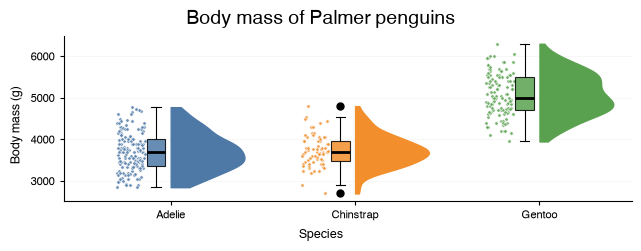

In [11]:
RaincloudPlot(
    data=chart_data,
    # jitter the rain instead of packing it
    mode=SWARM_MODE.STRIP,
    # narrow the jitter band to half of the rain width
    jitter=0.2,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Box outliers

The box shows the values beyond 1.5 times the interquartile range as outlier markers. They are already in the rain, so hide them with `show_outliers=False` when the box should stay a plain summary.

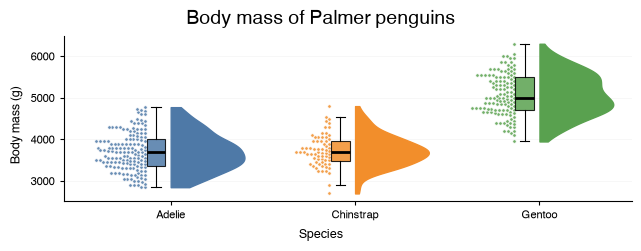

In [12]:
RaincloudPlot(
    data=chart_data,
    # the rain already shows every value
    show_outliers=False,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Raincloud orientation

To change the orientation of the rainclouds, add the `orientation` attribute, which supports the following values:

| Value | Description |
| :---- | :---------- |
| `"vertical"` | The rainclouds are vertical, one per category along the x-axis, the cloud on the right, the box and the rain on its left (the default). |
| `"horizontal"` | The rainclouds are horizontal, one per category along the y-axis, the cloud above, the box and the rain below it. |

The `datachart` package provides the [datachart.constants.ORIENTATION](../../../references/constants/#datachart.constants.ORIENTATION) constant with these values.

In [13]:
from datachart.constants import ORIENTATION

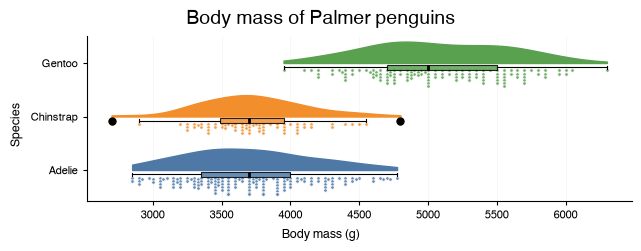

In [14]:
RaincloudPlot(
    data=chart_data,
    # change the orientation of the rainclouds
    orientation=ORIENTATION.HORIZONTAL,
    title="Body mass of Palmer penguins",
    # swap the axis labels to match the orientation
    xlabel="Body mass (g)",
    ylabel="Species",
    figsize=FIG_SIZE.FULL_SHORT,
    # the value axis is now the x-axis
    show_grid=SHOW_GRID.X,
).show()

### Emphasis

To draw attention to one group, add the `emphasis` attribute. The `emphasis` list aligns with the group **labels** of one call, in the order the labels first appear in the data — here Adelie, Chinstrap, Gentoo — and applies to the cloud, the rain, and the box of the group together. Each entry is one of the following roles:

| Role | Description |
| :--- | :---------- |
| `"background"` | Mutes the group into the theme's muted color and alpha. |
| `"highlight"` | Bolds the edges of the cloud, the rain, and the box. |
| `None` | Leaves the group unchanged. |

A single value applies to every group. The [datachart.constants.EMPHASIS](../../../references/constants/#datachart.constants.EMPHASIS) constant holds the roles; the [highlighting guide](../../styling/highlighting.ipynb) covers emphasis across chart types and themes.

In [15]:
from datachart.constants import EMPHASIS

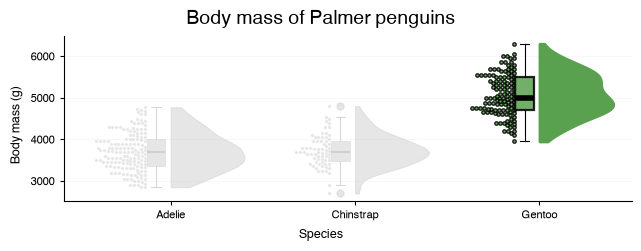

In [16]:
RaincloudPlot(
    data=chart_data,
    # one role per group label: Adelie, Chinstrap, Gentoo
    emphasis=[EMPHASIS.BACKGROUND, EMPHASIS.BACKGROUND, EMPHASIS.HIGHLIGHT],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Reference lines

A reference line puts a threshold or a summary value next to the rainclouds. To add horizontal lines, add the `hlines` attribute with the [datachart.typings.HLinePlotAttrs](../../../references/typings/#datachart.typings.HLinePlotAttrs) typing, which is either a `dict` or a `List[dict]`; vertical lines use `vlines` and the [datachart.typings.VLinePlotAttrs](../../../references/typings/#datachart.typings.VLinePlotAttrs) typing.

In [17]:
from datachart.constants import LINE_STYLE

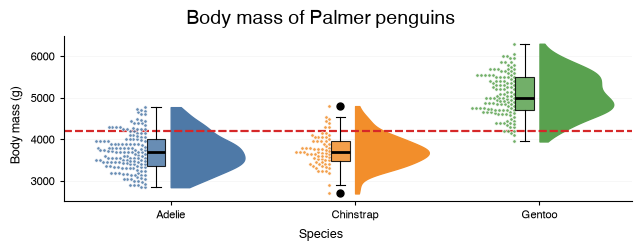

In [18]:
mean_mass = sum(penguin["value"] for penguin in chart_data) / len(chart_data)

RaincloudPlot(
    data=chart_data,
    # add a horizontal line at the mean body mass of all penguins
    hlines={
        "y": mean_mass,
        "style": {
            "plot_hline_color": "#d62728",
            "plot_hline_style": LINE_STYLE.DASHED,
            "plot_hline_width": 1.5,
            "plot_hline_alpha": 0.8,
        },
    },
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Multiple Raincloud Plots

To create multiple raincloud plots, pass a list of lists to the `data` argument. Each inner list holds the data points of one chart, and every chart draws in its own subplot — three parts per group leave no room to overlay a second dataset at the same positions. The `subtitle` becomes the subplot title and the `title`, `xlabel` and `ylabel` are positioned to be global for all charts. The `max_cols` attribute limits the number of columns, and `sharex` and `sharey` share an axis across the subplots; a shared axis is labeled once, on the outer subplots only.

`body_mass_by_sex` splits the penguins of the hidden cell into the 165 female and the 168 male penguins (the 9 penguins without a recorded sex are left out), one list of data points per sex.

In [19]:
SEXES = ["Female", "Male"]

# one list of data points per sex; the penguins without a recorded sex are left out
body_mass_by_sex = [
    [
        {"label": penguin["species"], "value": mass}
        for penguin in PENGUINS
        if penguin["sex"] == sex
        for mass in penguin["body_mass"]
    ]
    for sex in SEXES
]

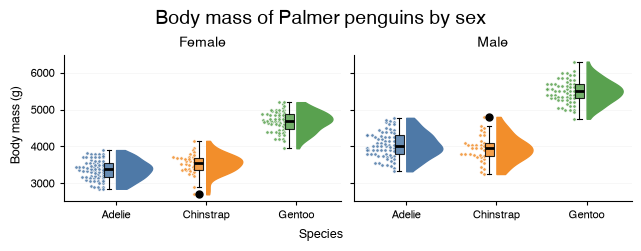

In [20]:
RaincloudPlot(
    # use a list of lists to define multiple raincloud plots
    data=body_mass_by_sex,
    # one subplot title per chart
    subtitle=SEXES,
    title="Body mass of Palmer penguins by sex",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
    # the same mass axis for both charts
    sharey=True,
).show()

## Composing rainclouds

A raincloud figure composes like any other chart. [datachart.utils.Panel](../../../references/utils/#datachart.utils.Panel) overlays it with other charts on shared axes: the groups keep their positions, so a reference chart of the same categories lines up with them. Here a [datachart.charts.LineChart](../../../references/charts/#datachart.charts.LineChart) traces the mean body mass across the species, one point per category position.

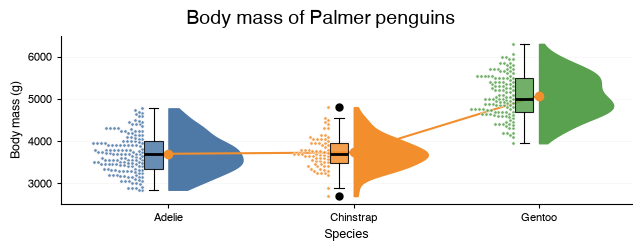

In [21]:
from datachart.charts import LineChart
from datachart.utils import Panel

SPECIES = ["Adelie", "Chinstrap", "Gentoo"]
mean_by_species = [
    {
        "x": i + 1,
        "y": sum(p["value"] for p in chart_data if p["label"] == species)
        / sum(1 for p in chart_data if p["label"] == species),
    }
    for i, species in enumerate(SPECIES)
]

Panel(
    [
        RaincloudPlot(data=chart_data),
        # the means, one per category position
        LineChart(data=mean_by_species, style={"plot_line_marker": "o"}),
    ],
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel_left="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

[datachart.utils.Grid](../../../references/utils/#datachart.utils.Grid) arranges rainclouds next to other figures. A raincloud of the flipper lengths (`flipper_data` from the hidden cell) sits beside the body mass one.

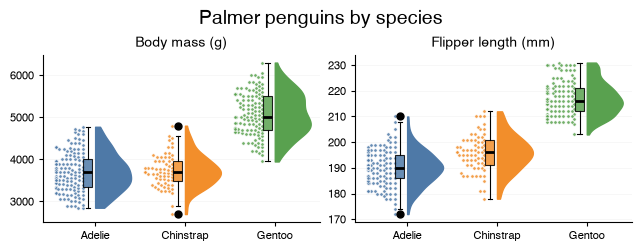

In [22]:
from datachart.utils import Grid

Grid(
    [
        RaincloudPlot(data=chart_data, title="Body mass (g)"),
        RaincloudPlot(data=flipper_data, title="Flipper length (mm)"),
    ],
    title="Palmer penguins by species",
    figsize=FIG_SIZE.FULL_SHORT,
).show()

## Additional Features

### Logarithmic scale

To draw the value axis on a logarithmic scale, add the `scaley` attribute with a value of the [datachart.constants.SCALE](../../../references/constants/#datachart.constants.SCALE) constant. The cloud, the rain, and the box all follow the scaled axis.

In [23]:
from datachart.constants import SCALE

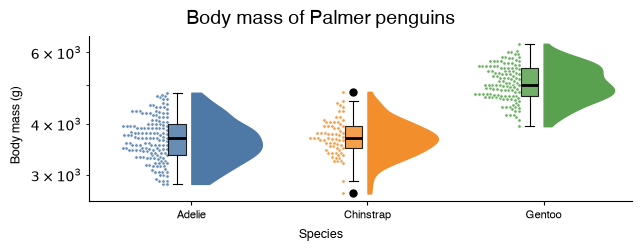

In [24]:
RaincloudPlot(
    data=chart_data,
    # draw the value axis on a logarithmic scale
    scaley=SCALE.LOG,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

### Custom data keys

If the data points hold the label and the value under other keys, add the `label` and `value` attributes with the key names, so the data need not be reshaped.

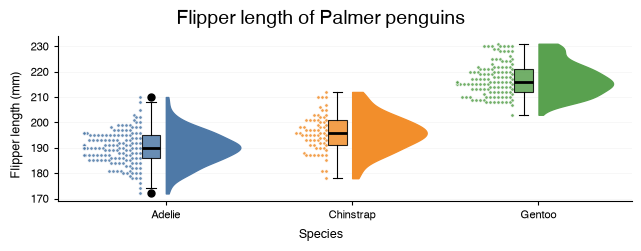

In [25]:
flipper_records = [
    {"species": penguin["species"], "flipper_mm": length}
    for penguin in PENGUINS
    for length in penguin["flipper_length"]
]

RaincloudPlot(
    data=flipper_records,
    # the keys holding the label and the value
    label="species",
    value="flipper_mm",
    title="Flipper length of Palmer penguins",
    xlabel="Species",
    ylabel="Flipper length (mm)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
).show()

## Saving the Chart as an Image

To save the chart as an image, use the [datachart.utils.save_figure](../../../references/utils#datachart.utils.save_figure) function.

In [26]:
from datachart.utils import save_figure

figure = RaincloudPlot(
    data=chart_data,
    title="Body mass of Palmer penguins",
    xlabel="Species",
    ylabel="Body mass (g)",
    figsize=FIG_SIZE.FULL_SHORT,
    show_grid=SHOW_GRID.Y,
)
save_figure(figure, "./fig_raincloud_plot.png", dpi=300)

The figure should be saved in the current working directory.